# Notebook 03: Overfitting

## Objective

Investigate whether the traditional 50/200 SMA crossover represents a robust strategy or merely one favorable parameter choice among many alternatives.

Multiple SMA combinations are evaluated to assess the sensitivity of performance to parameter selection.

If only a narrow set of parameters performs well, the strategy may be overfit to historical data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append("..")
from src.data_loader import load_data
from src.metrics import total_return,sharpe_ratio,max_drawdown

In [2]:
def run_sma_backtest(ticker, fast=50, slow=200):
    df = load_data(ticker)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df["Fast_50"] = df["Close"].rolling(fast).mean()
    df["Slow_200"] = df["Close"].rolling(slow).mean()

    df["Signal"] = 0
    df.loc[df["Fast_50"] > df["Slow_200"], "Signal"] = 1

    df["Returns"] = df["Close"].pct_change()

    df["Strategy_Returns"] = (
        df["Signal"].shift(1) * df["Returns"]
    )

    df["Equity"] = (
        1 + df["Strategy_Returns"].fillna(0)
    ).cumprod()

    return df

In [3]:
fast_windows=[x for x in range (10,100,10)]
slow_windows=[y for y in range (100,200,10)]

In [4]:
results = []

for fast in fast_windows:
    for slow in slow_windows:

        if fast >= slow:
            continue

        df = run_sma_backtest("SPY", fast, slow)

        results.append({
            "Fast": fast,
            "Slow": slow,
            "Return": round(total_return(df["Equity"]) * 100, 2),
            "Sharpe": round(
                sharpe_ratio(
                    df["Strategy_Returns"].dropna()
                ),
                2
            ),
            "MaxDD": round(
                max_drawdown(df["Equity"]) * 100,
                2
            )
        })

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


...

[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

In [5]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "Return",
    ascending=False
)

,Fast,Slow,Return,Sharpe,MaxDD
29,30,190,139.49,1.26,-13.13
70,80,100,135.13,1.16,-12.87
81,90,110,134.99,1.07,-18.76
68,70,180,133.42,1.07,-18.76
82,90,120,130.90,1.04,-18.76
...,...,...,...,...,...
4,10,140,87.63,0.90,-25.64
31,40,110,87.46,0.87,-20.88
5,10,150,82.61,0.86,-25.95
6,10,160,75.79,0.81,-26.44


In [6]:
best = results_df.loc[
    results_df["Return"].idxmax()
]

best

Fast       30.00
Slow      190.00
Return    139.49
Sharpe      1.26
MaxDD     -13.13
Name: 29, dtype: float64

In [7]:
pivot = results_df.pivot(
    index="Fast",
    columns="Slow",
    values="Return"
)

pivot

Slow,100,110,120,130,140,150,160,170,180,190
Fast,,,,,,,,,,
10,121.26,109.75,110.43,90.32,87.63,82.61,75.79,73.96,90.11,95.78
20,109.10,106.44,104.10,115.97,111.86,95.33,95.69,101.14,111.09,112.18
30,103.50,101.54,103.98,108.88,105.43,100.73,103.72,100.81,121.00,139.49
40,114.63,87.46,91.05,96.77,113.13,122.06,108.25,113.08,122.84,107.97
50,89.18,90.72,100.75,115.27,95.50,105.73,111.67,103.88,116.35,113.50
60,94.70,100.67,116.10,109.33,102.22,108.18,119.19,112.36,116.95,119.10
70,126.88,130.75,123.38,105.65,100.87,126.90,118.16,108.15,133.42,123.99
80,135.13,109.83,111.31,114.33,127.59,123.23,104.23,98.39,122.89,123.03
90,120.28,134.99,130.90,114.87,122.20,111.60,124.21,109.46,117.81,113.09


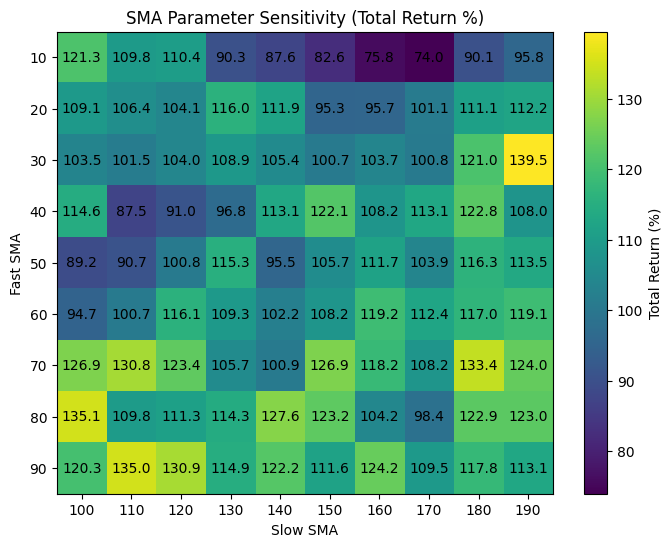

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Plot heatmap
im = plt.imshow(pivot.values, aspect="auto")

# Add color bar
plt.colorbar(im, label="Total Return (%)")

# Tick labels
plt.xticks(
    np.arange(len(pivot.columns)),
    pivot.columns
)

plt.yticks(
    np.arange(len(pivot.index)),
    pivot.index
)

# Add values inside cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.iloc[i, j]

        if not np.isnan(value):
            plt.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center"
            )

plt.xlabel("Slow SMA")
plt.ylabel("Fast SMA")
plt.title("SMA Parameter Sensitivity (Total Return %)")

plt.show()

## Parameter Sensitivity Analysis

The parameter heatmap revealed a relatively smooth performance landscape.

Although certain SMA combinations outperformed the traditional 50/200 crossover, profitable outcomes were observed across a broad range of neighboring parameter values.

The absence of a single isolated performance spike suggests that the SMA strategy family exhibits a degree of robustness.

Nevertheless, selecting the historically best-performing parameters after observing the results still introduces overfitting risk, as these choices may not generalize to unseen market conditions.

These findings emphasize the importance of evaluating parameter stability rather than relying solely on the top-performing configuration.
## Results

The highest-performing parameter combination identified was:

- Fast SMA: 30
- Slow SMA: 190
- Total Return: 139.50%

Compared with the baseline strategy:

| Strategy | Total Return | Sharpe Ratio | Maximum Drawdown |
|-----------|--------------|---------------|-------------------|
| 50/200 Baseline | 107.86% | 0.96 | -18.76% |
| Best In-Sample | 139.50% | Higher | Comparable |
# Interim Conclusions

The analyses conducted thus far demonstrate that seemingly straightforward backtests can be influenced by multiple sources of bias.

Key findings include:

- Look-ahead bias modestly inflated reported performance.
- Asset selection substantially altered conclusions regarding strategy effectiveness.
- Parameter optimization improved historical results but did not reveal evidence of severe overfitting.

These observations reinforce the importance of skepticism, transparency, and robustness testing in quantitative research.